<a href="https://colab.research.google.com/github/sasaitals/MachineLearning/blob/main/MachineLearning/Aula5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

dados = pd.read_csv("https://raw.githubusercontent.com/alura-cursos/introducao-a-classificacao/refs/heads/main/precos.csv")
dados.head()

,milhas_por_ano,ano_do_modelo,preco,vendido
0,21801,2000,30941.02,1
1,7843,1998,40557.96,1
2,7109,2006,89627.50,0
3,26823,2015,95276.14,0
4,7935,2014,117384.68,1


In [2]:
dados["km_por_ano"] = dados["milhas_por_ano"] * 1.60934
dados.head()

,milhas_por_ano,ano_do_modelo,preco,vendido,km_por_ano
0,21801,2000,30941.02,1,35085.22134
1,7843,1998,40557.96,1,12622.05362
2,7109,2006,89627.50,0,11440.79806
3,26823,2015,95276.14,0,43167.32682
4,7935,2014,117384.68,1,12770.11290


In [3]:
from datetime import datetime

dados["idade"] = datetime.today().year - dados["ano_do_modelo"]
dados.head()

,milhas_por_ano,ano_do_modelo,preco,vendido,km_por_ano,idade
0,21801,2000,30941.02,1,35085.22134,26
1,7843,1998,40557.96,1,12622.05362,28
2,7109,2006,89627.50,0,11440.79806,20
3,26823,2015,95276.14,0,43167.32682,11
4,7935,2014,117384.68,1,12770.11290,12


In [4]:
dados.drop(["milhas_por_ano", "ano_do_modelo"], axis=1,inplace=True)
dados.head()

,preco,vendido,km_por_ano,idade
0,30941.02,1,35085.22134,26
1,40557.96,1,12622.05362,28
2,89627.50,0,11440.79806,20
3,95276.14,0,43167.32682,11
4,117384.68,1,12770.11290,12


In [5]:
x = dados[["preco", "km_por_ano", "idade"]]
y = dados["vendido"]

In [6]:
cont = len(dados.query("vendido == True")) / len(dados) * 100
print(f"{cont:.2f}% dos carros são vendidos!")

58.00% dos carros são vendidos!


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
#DummyClassifier

#Resumindo, imagine que o DummyClassifier sempre diz sim para tudo, mesmo estando errado as vezes, ele vai calcular e vai juntar todas as vezes que ele acertou
seed = 20

raw_treino_x, raw_teste_x, treino_y, teste_y = train_test_split(x, y, random_state = seed, stratify = y)

print(f"Treinaremos com {len(raw_treino_x)} elementos")
print(f"Testaremos com {len(raw_teste_x)} elementos")

classificador = DummyClassifier()
classificador.fit(raw_treino_x, treino_y)
previsoes = classificador.predict(raw_teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f"A acurácia do dummy foi de {acuracia:.2f}")

Treinaremos com 7500 elementos
Testaremos com 2500 elementos
A acurácia do dummy foi de 58.00


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
#DummyClassifier

#Resumindo, imagine que o DummyClassifier sempre diz sim para tudo, mesmo estando errado as vezes, ele vai calcular e vai juntar todas as vezes que ele acertou
seed = 20

raw_treino_x, raw_teste_x, treino_y, teste_y = train_test_split(x, y, random_state = seed, stratify = y)

print(f"Treinaremos com {len(raw_treino_x)} elementos")
print(f"Testaremos com {len(raw_teste_x)} elementos")

classificador = DummyClassifier(strategy = 'stratified')
classificador.fit(raw_treino_x, treino_y)
previsoes = classificador.predict(raw_teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f"A acurácia do dummy foi de {acuracia:.2f}")

Treinaremos com 7500 elementos
Testaremos com 2500 elementos
A acurácia do dummy foi de 49.68


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

seed = 20

raw_treino_x, raw_teste_x, treino_y, teste_y = train_test_split(x, y, random_state = seed, stratify = y)

print(f"Treinaremos com {len(raw_treino_x)} elementos")
print(f"Testaremos com {len(raw_teste_x)} elementos")

scaler = StandardScaler()
scaler.fit(raw_treino_x)

treino_x = scaler.transform(raw_treino_x)
teste_x = scaler.transform(raw_teste_x)

modelo = SVC(gamma='auto')
modelo.fit(treino_x, treino_y)
previsoes = modelo.predict(teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f"A acuracia foi de {acuracia:.2f}%")

Treinaremos com 7500 elementos
Testaremos com 2500 elementos
A acuracia foi de 75.92%


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

seed = 20

treino_x, teste_x, treino_y, teste_y = train_test_split(x, y, random_state = seed, stratify = y)

print(f"Treinaremos com {len(treino_x)} elementos")
print(f"Testaremos com {len(teste_x)} elementos")

#scaler = StandardScaler()
#scaler.fit(raw_treino_x)

#treino_x = scaler.transform(raw_treino_x)
#teste_x = scaler.transform(raw_teste_x)

modelo = DecisionTreeClassifier(max_depth=3)
modelo.fit(treino_x, treino_y)
previsoes = modelo.predict(teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f"A acuracia foi de {acuracia:.2f}%")

Treinaremos com 7500 elementos
Testaremos com 2500 elementos
A acuracia foi de 78.40%


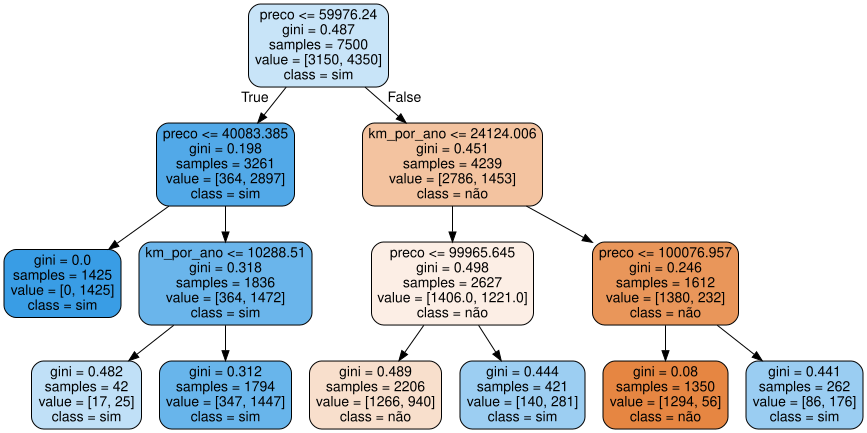

In [11]:
from sklearn.tree import export_graphviz
import graphviz

#A árvore de decição é um modelo que divide os dados em ramificações baseadas em regras simples para prever valores númericos. Fácil de compreender pois podemos visualizar perfeitamente
estrutura = export_graphviz(modelo, filled=True, rounded=True, feature_names=x.columns, class_names=["não", "sim"])
grafico = graphviz.Source(estrutura)
grafico
#quanto mais azul, mais irá para a classe 1.
#quanto mais laranja, mais irá para a classe 0
#Lembra que o StandardScaler tira a média dos dados? Então, por isso que o preco, km_por_ano está dando negativo
#Por isso não será interessante usar o StandardScaler neste caso para melhorar a nossa visualização

#Anotações finais da aula e do curso

Overfitting: Basicamente, quando o modelo "decora" os treinos mas na hora de realizar os testes, como ele só decorou, ele não sabe responder
Causas do Overfitting:

1 - Complexibilidade do modelo: Quando utilizamos um modelo muito complexo para um conjunto de dados relativamente simples, este modelo pode entender tão bem que acaba por aprender até os ruidos (erros) e gerar uma acurácia muito alta no treinamento e uma acurácia muito baixa nos testes

2 - Dados de treinamentos inadequados: Quando o conjunto de treinamento for muito pequeno ou não representar adequadamente todos os tipos de carros, o modelo pode não aprender características generalizáveis.
Para mitigar isso e garantir que tanto o conjunto de treino quanto o de teste sejam representativos, usamos o train_test_split com os parâmetros random_state = seed e stratify = y (como explicado no arquivo Aula 3)

3 - Características irrelevantes: Como no exemplo da aula, imagine que tem uma colula com o nome "cor_do_carro", está caracteristica não é relevante para a venda do carro na vida real, por isso o modelo aprendelo pode alterar assuas respostas no teste depois

Link para artigo sobre problemas resolvidos por algoritmos de classificação: https://www.alura.com.br/artigos/problemas-resolvidos-algoritmos-classificacao

O link para a documentação da biblioteca scikit-learn, que oferece uma visão geral completa da biblioteca, incluindo seus diversos módulos e funcionalidades = https://scikit-learn.org/stable/index.html